# AlexNet Benchmark

use PY310, py311 not support torch.compile, py39 not support libnvrtc.so compatibility

In [1]:
model_name = "wideresnet101-torch"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll


In [2]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=3):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Experimental

In [3]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

device = torch.device("cuda:0")
model = models.wide_resnet101_2().train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model = model.to(device)

df = pd.DataFrame()

### PyTorch (Baseline)

In [5]:

model_dynamo = torch.compile(model, backend="inductor")

image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)

output = model_dynamo(image)
grad = torch.randn_like(output)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()

baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=33, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=33, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-dynamo-gpu-forward:  [0.2662593591188596, 0.2618536816634532, 0.26209483947690415, 0.2620160567708471, 0.26214966350350494, 0.2627478120549213, 0.26241110943948814, 0.2624449645972121, 0.2626143070921315, 0.262567697347743, 0.2625187426203429]
0.262698021244128
torch-dynamo-gpu-backward:  [0.4586898897072391, 0.45869141625526083, 0.45878651976941154, 0.4586739811098718, 0.45875281085242253, 0.45875956272728624, 0.45869017363661907, 0.45869105877790894, 0.45883902617968797, 0.45916533201960275, 0.45968362286727943]
0.4588566721729627
       time      pass          item
0  0.254397   Forward  Torch Dynamo
0  0.459632  Backward  Torch Dynamo
0  0.714029      Full  Torch Dynamo
0  0.262698   Forward  Torch Dynamo
0  0.458857  Backward  Torch Dynamo
0  0.721555      Full  Torch Dynamo


In [5]:

model_dynamo = torch.compile(model, backend="inductor")

image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)

output = model_dynamo(image)
grad = torch.randn_like(output)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()
baseline_f = timeit("model_dynamo(image.to(device))", 33)
_ = timeit("torch.autograd.grad(output.to(device), [image.to(device)], grad.to(device), retain_graph=True)", 1)
baseline_b = timeit("torch.autograd.grad(output.to(device), [image.to(device)], grad.to(device), retain_graph=True)", 13)
"""
baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=33, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=33, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
"""
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

        time      pass          item
0   8.526765   Forward  Torch Dynamo
0  10.077033  Backward  Torch Dynamo
0  18.603798      Full  Torch Dynamo
0   8.527781   Forward  Torch Dynamo
0  14.594125  Backward  Torch Dynamo
0  23.121906      Full  Torch Dynamo


In [6]:
df.style.hide(axis="index")

time,pass,item
8.318419,Forward,Torch Dynamo
15.130816,Backward,Torch Dynamo
23.449236,Full,Torch Dynamo
7.930573,Forward,Torch Native
8.327795,Backward,Torch Native
16.258369,Full,Torch Native


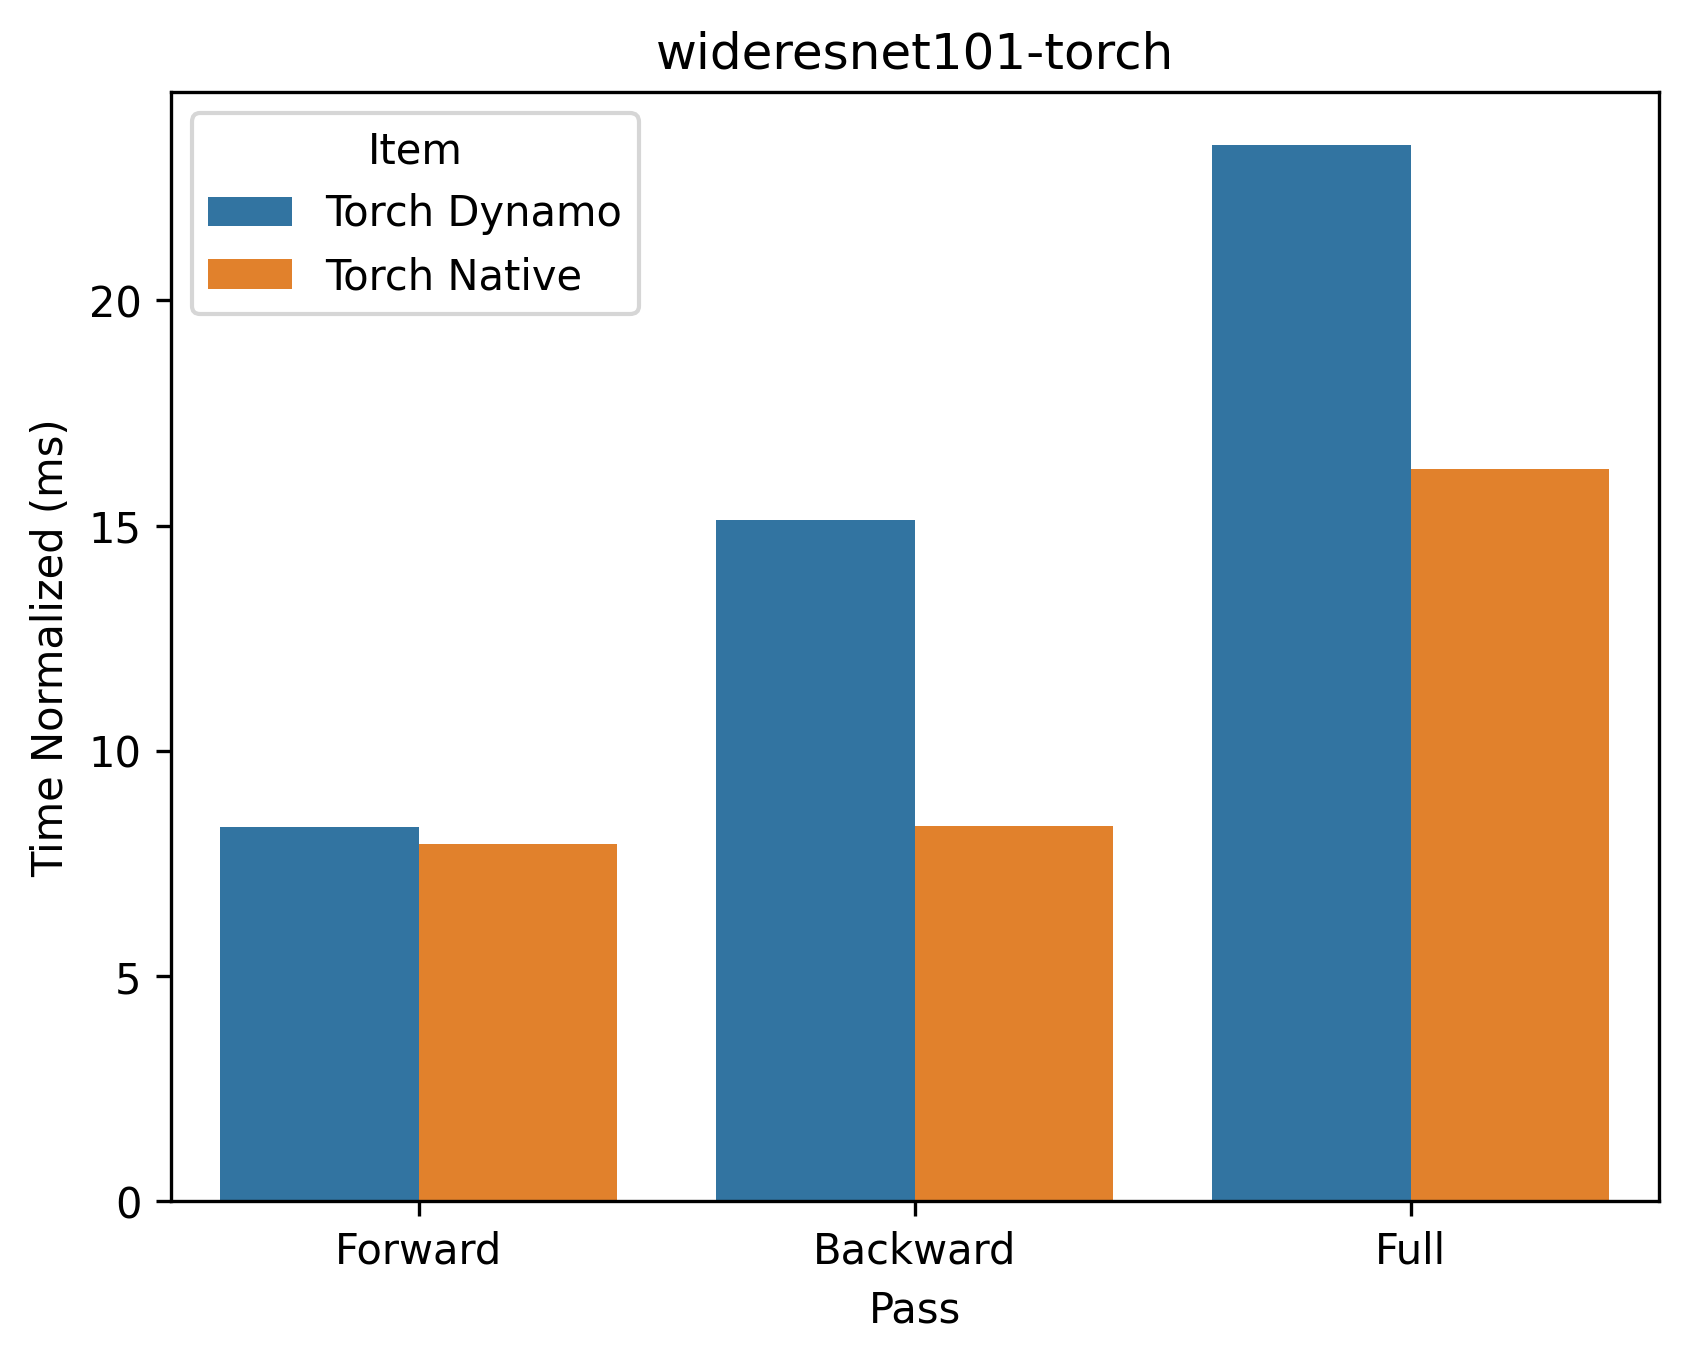

In [7]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [8]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,8.318419,Forward,Torch Dynamo,0.953375
0,7.930573,Forward,Torch Native,1.000000


In [9]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,15.130816,Backward,Torch Dynamo,0.550386
0,8.327795,Backward,Torch Native,1.000000


In [10]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,23.449236,Full,Torch Dynamo,0.693343
0,16.258369,Full,Torch Native,1.000000


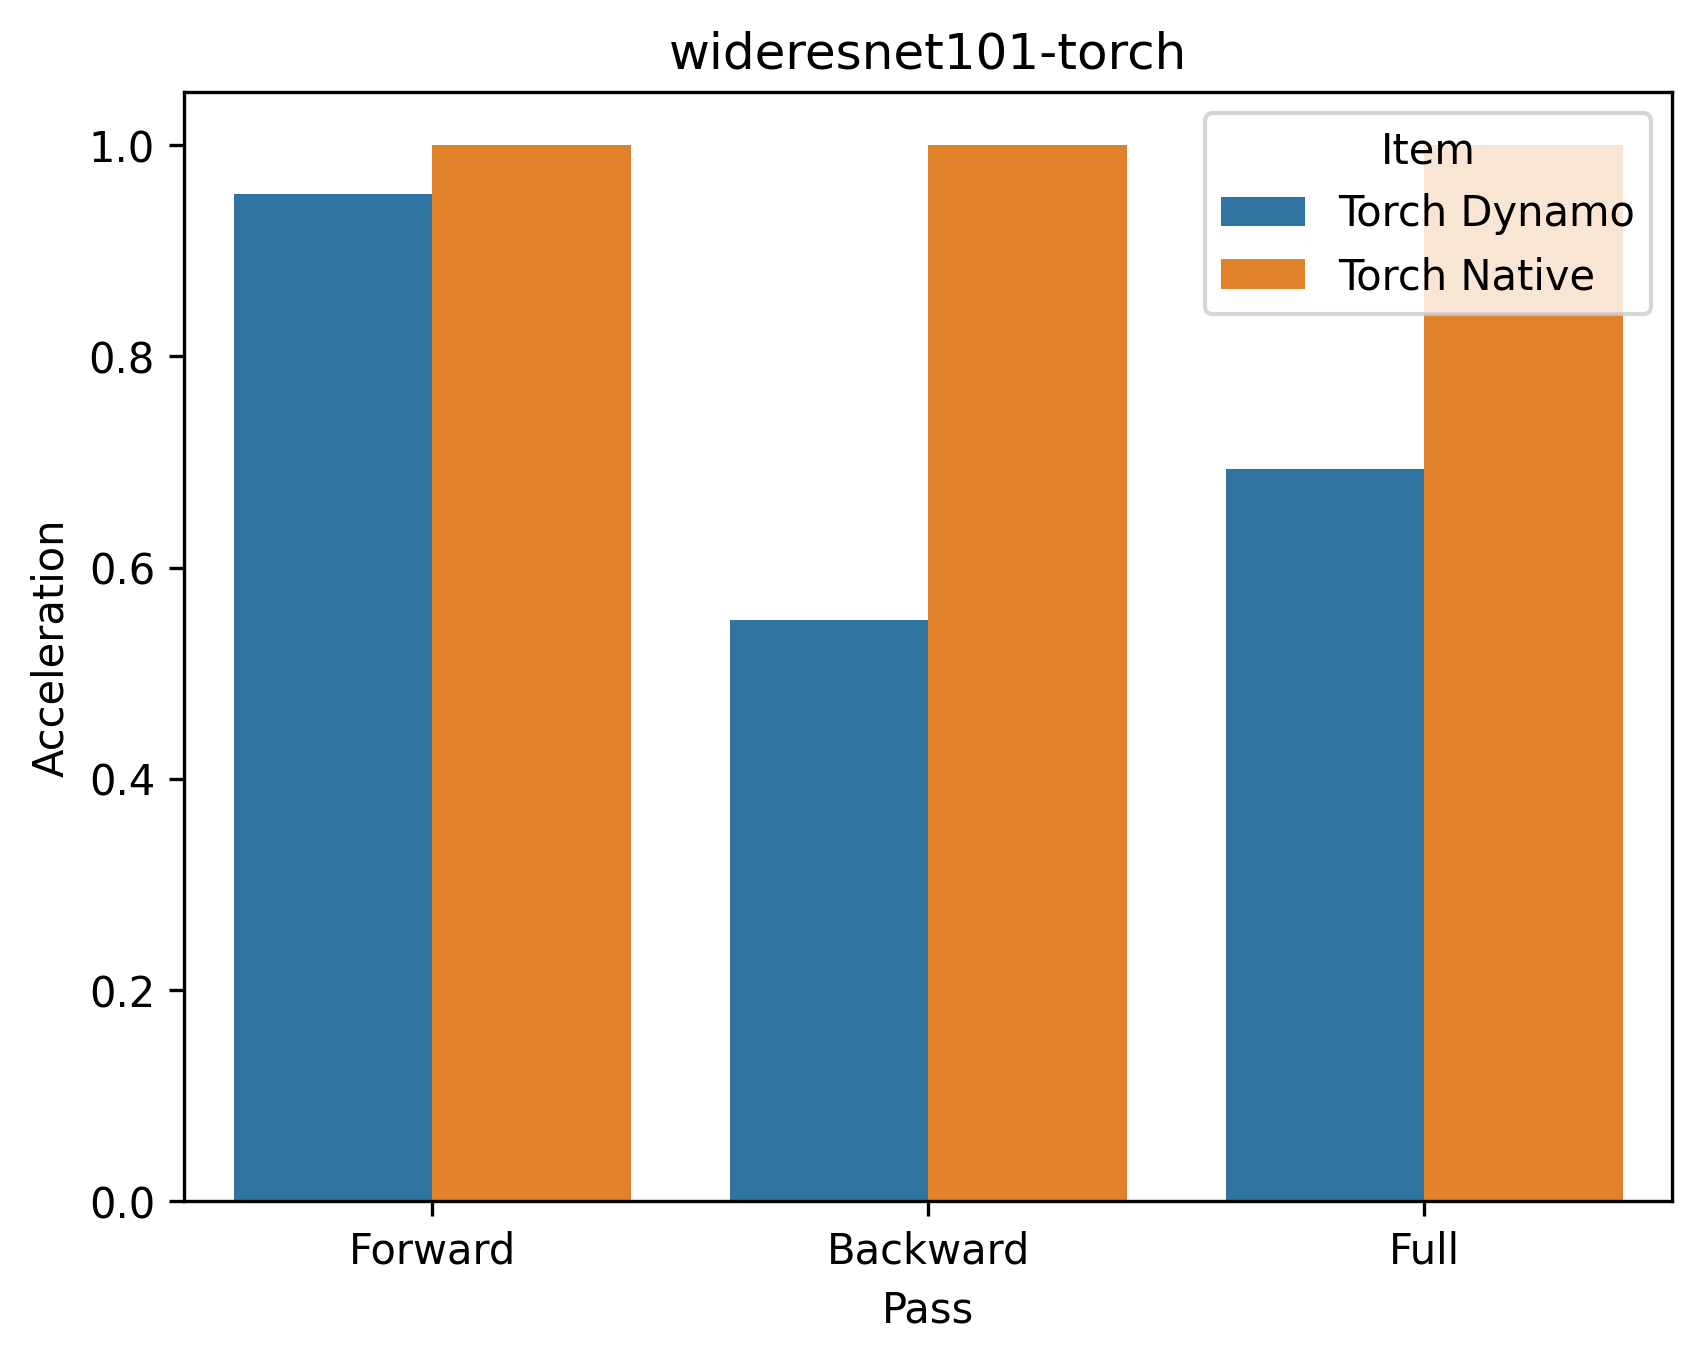

In [11]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")